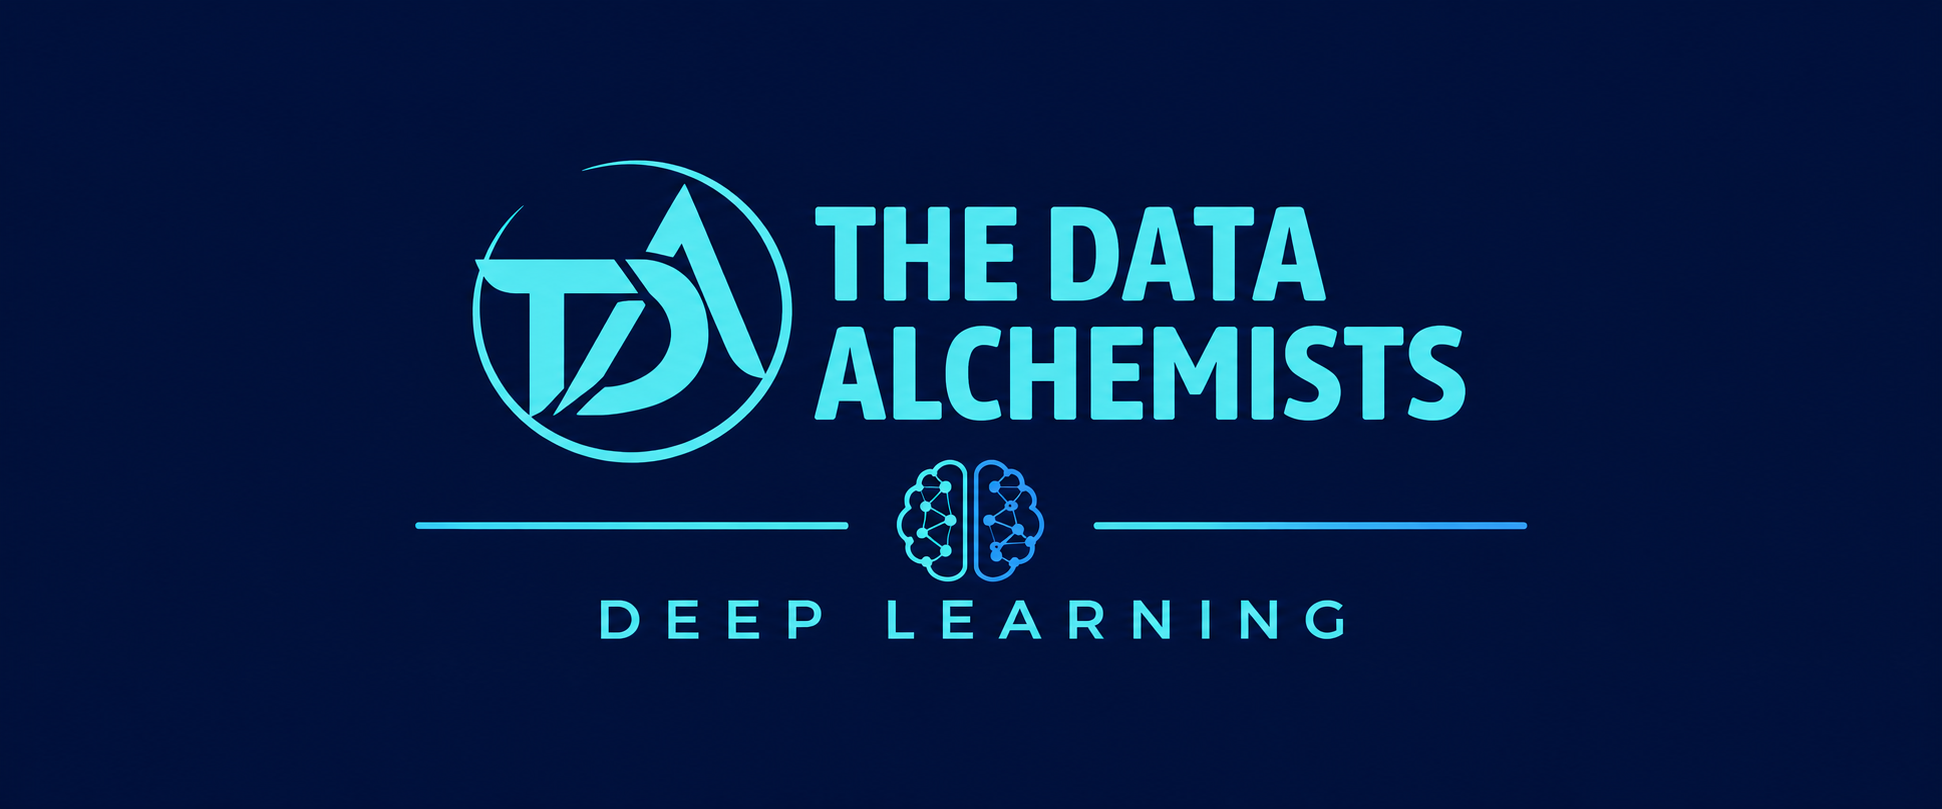

In [9]:
!pip install kaggle

**Importing the Dependencies**

In [10]:
import os
import json

from zipfile import ZipFile
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

**Data Collection- Kaggle API**

### Uploading `kaggle.json`

1.  **Download `kaggle.json`:** If you haven't already, download your `kaggle.json` file from your Kaggle account (Profile -> Account -> API -> Create New API Token).
2.  **Upload to Colab:** Click the folder icon on the left sidebar in Colab to open the file browser. Then, click the 'Upload to session storage' icon (it looks like a file with an arrow pointing up) and select your `kaggle.json` file.
3.  **Move the file:** Once uploaded, you'll need to move it to the correct directory and set the permissions. Execute the following cells:

In [8]:
!pip install -q -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.2 MB/s eta 0:00:00


In [11]:
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
100% 25.7M/25.7M [00:00<00:00, 187MB/s]



In [12]:
!ls

imdb-dataset-of-50k-movie-reviews.zip  sample_data


In [13]:
# unzip the dataset file
with ZipFile("imdb-dataset-of-50k-movie-reviews.zip", "r") as zip_ref:
  zip_ref.extractall()

In [14]:
!ls

'IMDB Dataset.csv'   imdb-dataset-of-50k-movie-reviews.zip   sample_data


**Loading teh Dataset**

In [15]:
data = pd.read_csv("/content/IMDB Dataset.csv")

In [16]:
data.shape

(50000, 2)

In [17]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [18]:
data.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [39]:
# Basic dataset information

print("Dataset Shape:", data.shape)
print("\nColumn Names:")
print(data.columns.tolist())

print("\nDataset Information:")
data.info()

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDuplicate Reviews:", data["review"].duplicated().sum())

Dataset Shape: (50000, 2)

Column Names:
['review', 'sentiment']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 781.4+ KB

Missing Values:
review       0
sentiment    0
dtype: int64

Duplicate Reviews: 418


In [19]:
data["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


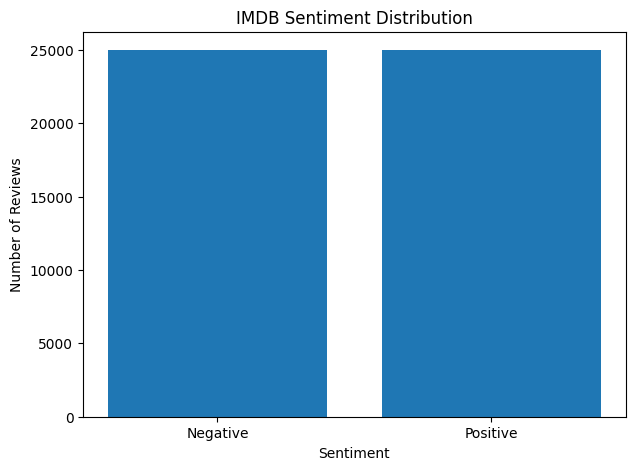

In [40]:
import matplotlib.pyplot as plt

sentiment_counts = data["sentiment"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Negative", "Positive"],
    [
        sentiment_counts[0],
        sentiment_counts[1]
    ]
)

plt.title("IMDB Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [41]:
# Calculate number of words in each review

data["review_length"] = data["review"].apply(
    lambda x: len(x.split())
)

print("Average review length:",
      data["review_length"].mean())

print("Median review length:",
      data["review_length"].median())

print("Maximum review length:",
      data["review_length"].max())

print("Minimum review length:",
      data["review_length"].min())

Average review length: 231.15694
Median review length: 173.0
Maximum review length: 2470
Minimum review length: 4


In [42]:
positive_lengths = data[
    data["sentiment"] == 1
]["review_length"]

negative_lengths = data[
    data["sentiment"] == 0
]["review_length"]

print("Average positive review length:",
      positive_lengths.mean())

print("Average negative review length:",
      negative_lengths.mean())

Average positive review length: 232.84932
Average negative review length: 229.46456


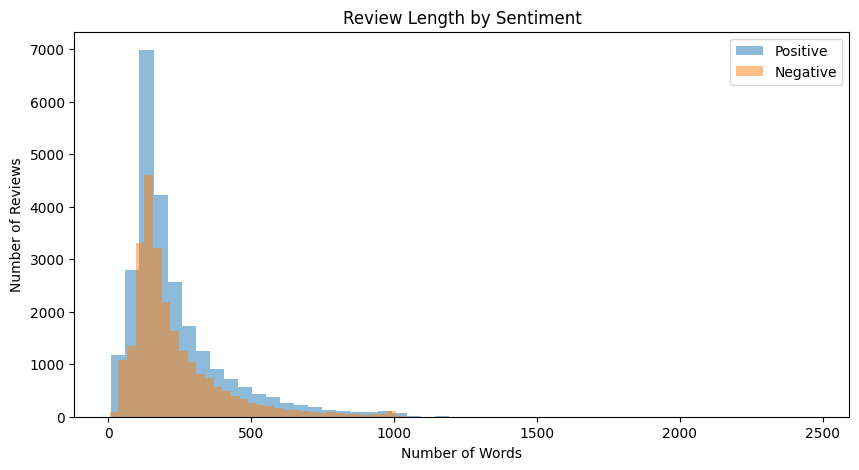

In [43]:
plt.figure(figsize=(10, 5))

plt.hist(
    positive_lengths,
    bins=50,
    alpha=0.5,
    label="Positive"
)

plt.hist(
    negative_lengths,
    bins=50,
    alpha=0.5,
    label="Negative"
)

plt.title("Review Length by Sentiment")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.legend()

plt.show()

In [20]:
data.replace({"sentiment": {"positive": 1, "negative": 0}}, inplace=True)

/tmp/ipykernel_2124/2568826810.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({"sentiment": {"positive": 1, "negative": 0}}, inplace=True)


In [21]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [22]:
data["sentiment"].value_counts()

,count
sentiment,
1,25000
0,25000


In [23]:
# split data into training data and test data
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

In [24]:
print(train_data.shape)
print(test_data.shape)

(40000, 2)
(10000, 2)


**Data Preprocessing**

In [25]:
# Tokenize text data
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(train_data["review"])
X_train = pad_sequences(tokenizer.texts_to_sequences(train_data["review"]), maxlen=200)
X_test = pad_sequences(tokenizer.texts_to_sequences(test_data["review"]), maxlen=200)

In [26]:
print(X_train)

[[1935    1 1200 ...  205  351 3856]
 [   3 1651  595 ...   89  103    9]
 [   0    0    0 ...    2  710   62]
 ...
 [   0    0    0 ... 1641    2  603]
 [   0    0    0 ...  245  103  125]
 [   0    0    0 ...   70   73 2062]]


In [27]:
print(X_test)

[[   0    0    0 ...  995  719  155]
 [  12  162   59 ...  380    7    7]
 [   0    0    0 ...   50 1088   96]
 ...
 [   0    0    0 ...  125  200 3241]
 [   0    0    0 ... 1066    1 2305]
 [   0    0    0 ...    1  332   27]]


In [28]:
Y_train = train_data["sentiment"]
Y_test = test_data["sentiment"]

In [29]:
print(Y_train)

39087    0
30893    0
45278    1
16398    0
13653    0
        ..
11284    1
44732    1
38158    0
860      1
15795    1
Name: sentiment, Length: 40000, dtype: int64


**LSTM - Long Short-Term Memory**

In [30]:
# build the model

model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=128, input_length=200))
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
# compile the model
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

**Training the Model**

In [33]:
model.fit(X_train, Y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 272s 524ms/step - accuracy: 0.7887 - loss: 0.4562 - val_accuracy: 0.7638 - val_loss: 0.4941
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 304s 502ms/step - accuracy: 0.8581 - loss: 0.3461 - val_accuracy: 0.8476 - val_loss: 0.3770
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 253s 506ms/step - accuracy: 0.8487 - loss: 0.3544 - val_accuracy: 0.8436 - val_loss: 0.3815
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 253s 506ms/step - accuracy: 0.8798 - loss: 0.3008 - val_accuracy: 0.8571 - val_loss: 0.3441
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 249s 498ms/step - accuracy: 0.9030 - loss: 0.2471 - val_accuracy: 0.8759 - val_loss: 0.3145


**Model Evaluation**

In [34]:
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 152ms/step - accuracy: 0.8833 - loss: 0.3042
Test Loss: 0.30416110157966614
Test Accuracy: 0.8833000063896179


**Building a Predictive System**

In [35]:
def predict_sentiment(review):
  # tokenize and pad the review
  sequence = tokenizer.texts_to_sequences([review])
  padded_sequence = pad_sequences(sequence, maxlen=200)
  prediction = model.predict(padded_sequence)
  sentiment = "positive" if prediction[0][0] > 0.5 else "negative"
  return sentiment

In [36]:
# example usage
new_review = "This movie was fantastic. I loved it."
sentiment = predict_sentiment(new_review)
print(f"The sentiment of the review is: {sentiment}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step
The sentiment of the review is: positive


In [37]:
# example usage
new_review = "This movie was not that good"
sentiment = predict_sentiment(new_review)
print(f"The sentiment of the review is: {sentiment}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
The sentiment of the review is: negative


In [38]:
# example usage
new_review = "This movie was ok but not that good."
sentiment = predict_sentiment(new_review)
print(f"The sentiment of the review is: {sentiment}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
The sentiment of the review is: negative
